# Test simulator cases

Oreonspy foresees four cases based on the cavity round-trip time, required sampling frequency and chosen simulator accuracy for decaing electric field. For most of the required sampling frequency it is required an approximation to the closest computable frequency.

```real_f_calc()``` implements the algorithm used in oreonspy to choose between cases. In the second part of the notebook we attempt to test the approximation of the sampling frequency produced by the algorithm.

The most important variable in the algorithm is the number of roundtrips a photon will make inside the cavity in the timelap between two consecutive simulator samples ```N```.  The sampling frequency appoximation arises from the fact that ```N``` must be integer.

If ```N``` is smaller than one, the simulation is not possible using the difference equation. In this case, the simulator creates several simulators shifted in phase in order to satisfy the required sampling frequency.

The algorithm contains one constant (```N_epsilon```) which must be optimized for the best frequency approximation.\
Goal: Optimize ```N_epsilon```.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def number_of_subhistories(eta_2T):
    """
    Compute the number of phase-shifted subhistories required by the simulator.

    Parameters
    ----------
    eta_2T : float
        dimensionless round-trip normalized time-step expressing ratio
        between the sampling period and the cavity round-trip time.
        Must be strictly positive.

    Returns
    -------
    int
        Number of subhistories:
        - 1 when eta_2T < 1
        - round(eta_2T) otherwise
    """
    assert eta_2T > 0, "eta_2T must be positive"
    return int(np.round(1.0/eta_2T) if eta_2T < 1. else 1)


def round_for_inverse_curve(eta_2T):
    """
    Select the integer order used by the inverse-curve rounding rule.

    For each value `eta_2T`, let `k0 = floor(eta_2T)` and define the
    switching boundary

        b = 2*k0*(k0 + 1) / (2*k0 + 1)

    The returned integer is:
    - `k0` when `eta_2T < b`
    - `k0 + 1` otherwise

    Parameters
    ----------
    eta_2T : float or array-like of float
        Dimensionless normalized time-step value(s). Must be strictly positive.

    Returns
    -------
    tuple
        `(k, b)` where:
        - `k` is the selected integer order (int for scalar input, ndarray for array input)
        - `b` is the corresponding boundary value(s) used for the decision
    """
    assert np.all(np.asarray(eta_2T) > 0), "eta_2T must be positive"
    eta_2T_arr = np.asarray(eta_2T, dtype=float)

    k0 = np.floor(eta_2T_arr)
    b = 2 * k0 * (k0 + 1) / (2 * k0 + 1)
    k = np.where(eta_2T_arr < b, k0, k0 + 1).astype(int)

    # Preserve scalar return type for scalar input
    if np.isscalar(eta_2T):
        return int(k), float(b)
    return k, b


def real_f_calc(eta_2T, _2T, N_eff=1000):
    """
    Simulator case algorithm from cavity.simulation() in oreonspy 3.2.3.
    
    eta_2T = 1./(desired_f_calc * _2T)
    N_epsilon -- parameter of the algorithm
    _2T -- 2 times the cavity round trip time
    desired_f_calc -- the desired sampling frequency
    N_eff -- mean number of photon bounces in the cavity
    """
    N = 1  # Initlized to one in the constructor.
    n_of_subhistories = 1  # Initlized to one in the constructor.
    partial_Theta = False  # Initlized to False in the constructor.

    _N_eff_factor = 2

    if eta_2T < 1:
        n_of_subhistories = number_of_subhistories(eta_2T)
        f_calc = n_of_subhistories*(1/_2T)
    else:
        N_max = _N_eff_factor * N_eff
        if eta_2T > N_max:
            N = N_max
            f_calc = 1.0/(eta_2T*_2T)  # In this case desired f_calc is exactly computed.
            partial_Theta = True
        else:
            N = round_for_inverse_curve(eta_2T)[0]
            f_calc = 1.0/(N*_2T)  # in Hz

    Theta = 1.0 / f_calc  # in Seconds
            
    return f_calc, Theta, N, partial_Theta

In [3]:
# Define N_epsilon
N_epsilon = 0.234
_2T = 6000./3e8  # 2 times the cavity round trip time in seconds (for a 3000 m cavity)
my_N_eff = 10000

Unique quantized values: [1 2 3]
Monotonic non-decreasing: True


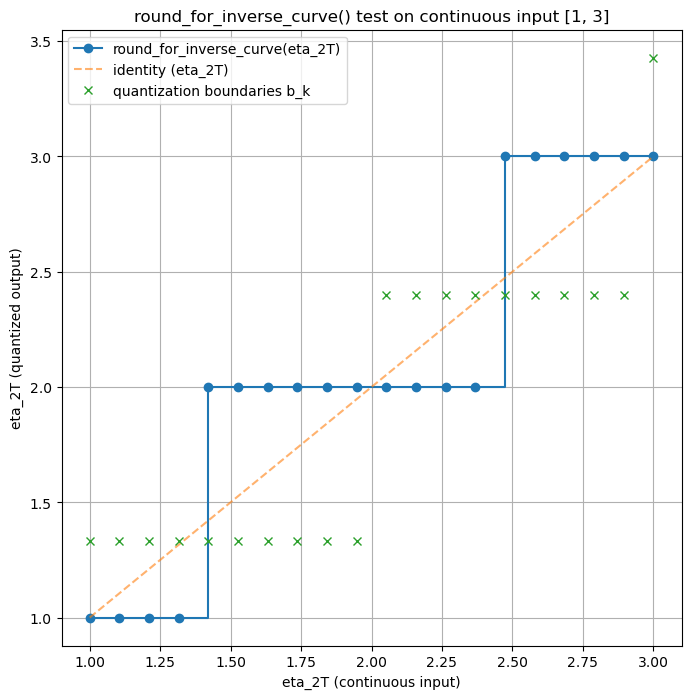

In [4]:
# Test round_for_inverse_curve() on a continuous interval N_pre in [1, 3]
eta_2T_test = np.linspace(1.0001, 3.0, 20)
eta_2T_rounded_test, boundary_test = round_for_inverse_curve(eta_2T_test)

# Basic checks
print("Unique quantized values:", np.unique(eta_2T_rounded_test))
print("Monotonic non-decreasing:", np.all(np.diff(eta_2T_rounded_test) >= 0))

# Plot quantization behavior
plt.figure(figsize=(8, 8))
plt.step(eta_2T_test, eta_2T_rounded_test, where="post", label="round_for_inverse_curve(eta_2T)", marker="o")
plt.plot(eta_2T_test, eta_2T_test, "--", alpha=0.6, label="identity (eta_2T)")
plt.plot(eta_2T_test, boundary_test, "x", label="quantization boundaries b_k")    
plt.xlabel("eta_2T (continuous input)")
plt.ylabel("eta_2T (quantized output)")
plt.title("round_for_inverse_curve() test on continuous input [1, 3]")
plt.grid(True)
plt.legend()
plt.show()

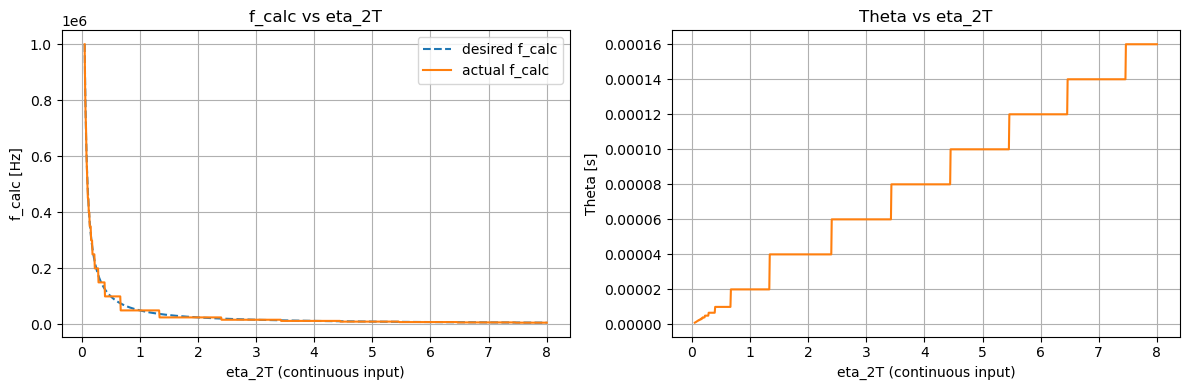

In [5]:
# Testbench for real_f_calc(): sweep eta_2T, plot f_calc and Theta

# Input
eta_2T_sweep = np.linspace(0.05, 8.0, 1000)
desired_f_sweep = 1.0 / (eta_2T_sweep * _2T)

# Output arrays
f_calc_sweep = np.empty_like(eta_2T_sweep)
Theta_sweep = np.empty_like(eta_2T_sweep)

for i, eta_2T in enumerate(eta_2T_sweep):
    f_calc, Theta, _, _ = real_f_calc(
        eta_2T=eta_2T,
        _2T=_2T,
        N_eff=my_N_eff,
    )
    f_calc_sweep[i] = f_calc
    Theta_sweep[i] = Theta

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(eta_2T_sweep, desired_f_sweep, label="desired f_calc", linestyle="--")
ax[0].plot(eta_2T_sweep, f_calc_sweep, label="actual f_calc")
ax[0].set_xlabel("eta_2T (continuous input)")
ax[0].set_ylabel("f_calc [Hz]")
ax[0].set_title("f_calc vs eta_2T")
ax[0].grid(True)
ax[0].legend()
#ax[0].set_ylim(0, 5.)

ax[1].plot(eta_2T_sweep, Theta_sweep, color="tab:orange")
ax[1].set_xlabel("eta_2T (continuous input)")
ax[1].set_ylabel("Theta [s]")
ax[1].set_title("Theta vs eta_2T")
ax[1].grid(True)

plt.tight_layout()
plt.show()

# Analyse the choice of the simulator case and the sampling frequency approximation

For an arbitrarily chosen cavity, plot the number of simulators involved (```number_of_2T_chains```).

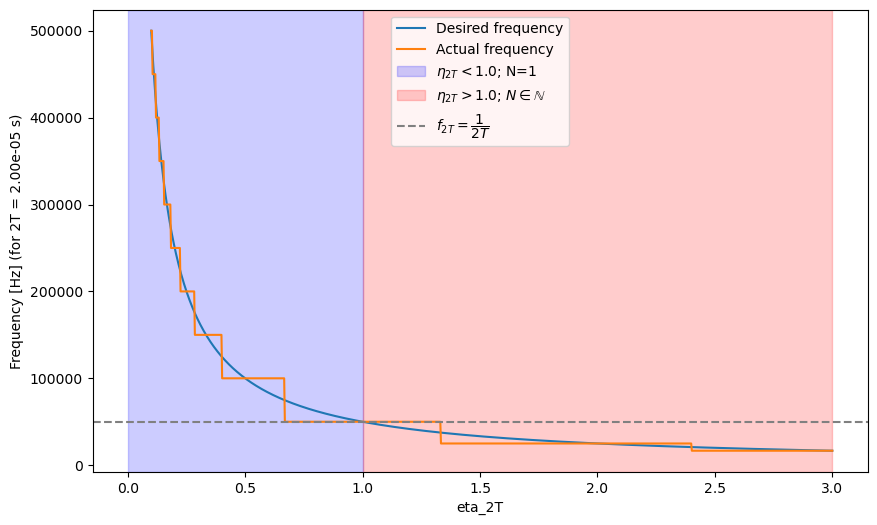

In [11]:
# Generate eta_2T values
#eta_2T_values = np.logspace(-2, 2, 10000)
eta_2T_values = np.linspace(0.1, 3, 1000)

# Compute number_of_subhistories for each eta_2T
n_of_subhistories = [number_of_subhistories(eta_2T) for eta_2T in eta_2T_values]

# Compute f_calc and Theta for each N_pre
desired_f_calc_values = []
actual_f_calc_values = []
Theta_values = []
partial_theta_values = []
N_values = []
for eta_2T in eta_2T_values:
    desired_f_calc = 1./(eta_2T * _2T)
    actual_f_calc, Theta, N, partial_Theta = real_f_calc(eta_2T, _2T=_2T, N_eff=my_N_eff)
    desired_f_calc_values.append(desired_f_calc)
    partial_theta_values.append(partial_Theta)
    actual_f_calc_values.append(actual_f_calc)
    Theta_values.append(Theta)
    N_values.append(N)

# Sanity check
assert all(isinstance(N, int) for N in N_values), "Not all elements in N_values are integers."

# Convert to numpy arrays for easier manipulation
desired_f_calc_values = np.array(desired_f_calc_values)
actual_f_calc_values = np.array(actual_f_calc_values)
Theta_values = np.array(Theta_values)

plt.figure(figsize=(10, 6))
plt.plot(eta_2T_values, desired_f_calc_values, label="Desired frequency")
plt.plot(eta_2T_values, actual_f_calc_values, label="Actual frequency")

# Add vertical color regions
plt.axvspan(0, 1.0, color='blue', alpha=0.2, label='$\eta_{2T} < 1.0$; N=1')
plt.axvspan(1.0, max(eta_2T_values), color='red', alpha=0.2, label='$\eta_{2T} > 1.0$; $N\in\mathbb{N}$')

plt.axhline(1.0 / _2T, color="gray", linestyle="--", linewidth=1.5, label=r"$f_{2T}=\dfrac{1}{2T}$")

plt.xlabel("eta_2T")
plt.ylabel("Frequency [Hz] (for 2T = {0:.2e} s)".format(_2T))
plt.legend()

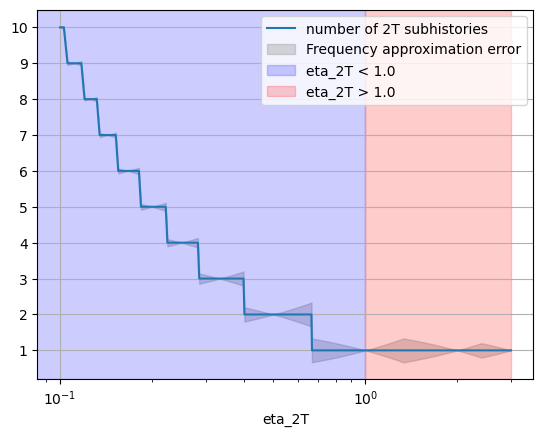

In [12]:
# Calculate the relative f_calc error
f_calc_accuracy = np.abs(actual_f_calc_values - desired_f_calc_values) / desired_f_calc_values

# Plot the results
plt.plot(eta_2T_values, n_of_subhistories, label='number of 2T subhistories')

# Plot the error area
plt.fill_between(eta_2T_values, 
                 [value - error for value, error in zip(n_of_subhistories, f_calc_accuracy)], 
                 [value + error for value, error in zip(n_of_subhistories, f_calc_accuracy)], 
                 color='gray', alpha=0.3, label='Frequency approximation error')

# Add vertical color regions
plt.axvspan(0, 1.0, color='blue', alpha=0.2, label='eta_2T < 1.0')
plt.axvspan(1.0, max(eta_2T_values), color='red', alpha=0.2, label='eta_2T > 1.0')

# Add labels and title
plt.xlabel('eta_2T')
plt.semilogx()
#plt.ylabel('value')
plt.yticks(range(min(n_of_subhistories), max(n_of_subhistories) + 1))
#plt.title('Number of 2T Chains vs N_pre')

# Add legend and grid
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

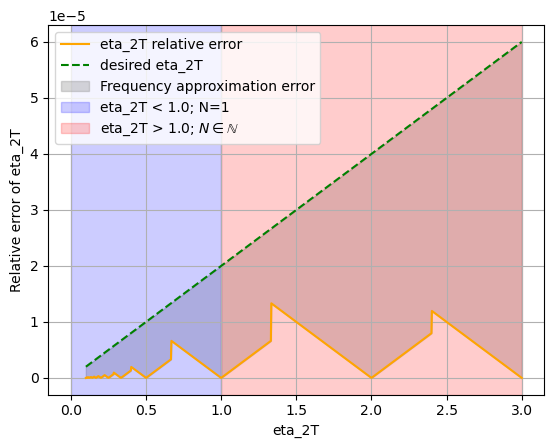

In [89]:
# time-step relative error
eta_2T_accuracy = np.abs(1/actual_f_calc_values - 1/desired_f_calc_values) / (1/desired_f_calc_values)
eta_2T_accuracy = np.abs(1/actual_f_calc_values - 1/desired_f_calc_values)

# Plot the results
#plt.plot(eta_2T_values, n_of_subhistories, label='number of 2T subhistories')

plt.plot(eta_2T_values, eta_2T_accuracy, label='eta_2T relative error', color='orange')
plt.plot(eta_2T_values, 1/desired_f_calc_values, label='desired eta_2T', linestyle='--', color='green')

# Plot the error area
plt.fill_between(eta_2T_values, 
                 [value - error for value, error in zip(eta_2T_accuracy, (eta_2T_accuracy-1/desired_f_calc_values))], 
                 [value + error for value, error in zip(eta_2T_accuracy, np.zeros_like(f_calc_accuracy))], 
                 color='gray', alpha=0.3, label='Frequency approximation error')

# Add vertical color regions
plt.axvspan(0, 1.0, color='blue', alpha=0.2, label='eta_2T < 1.0; N=1')
plt.axvspan(1.0, max(eta_2T_values), color='red', alpha=0.2, label='eta_2T > 1.0; $N\in\mathbb{N}$')

# Add labels and title
plt.xlabel('eta_2T')
plt.ylabel('Relative error of eta_2T')
#plt.yticks(range(min(n_of_subhistories), max(n_of_subhistories) + 1))
#plt.title('Number of 2T Chains vs N_pre')
# Add legend and grid
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

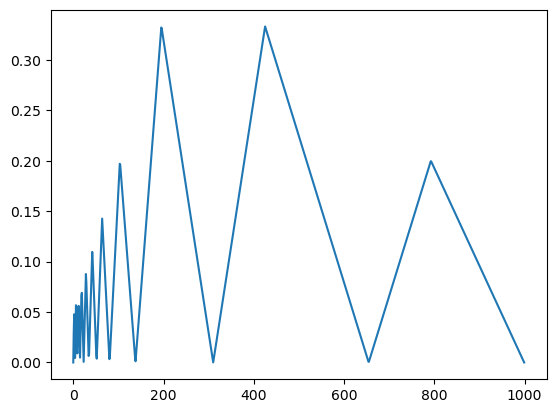

In [77]:
plt.plot(f_calc_accuracy)

# Analyse sampling frequency approximation accuracy

More suitable plot depicts directly the approximation accuracy.

At this point the parameter ```N_epsilon``` has been already optimized. It was initially 0,1 but it seems that the value of 0,25 assures better approximation.

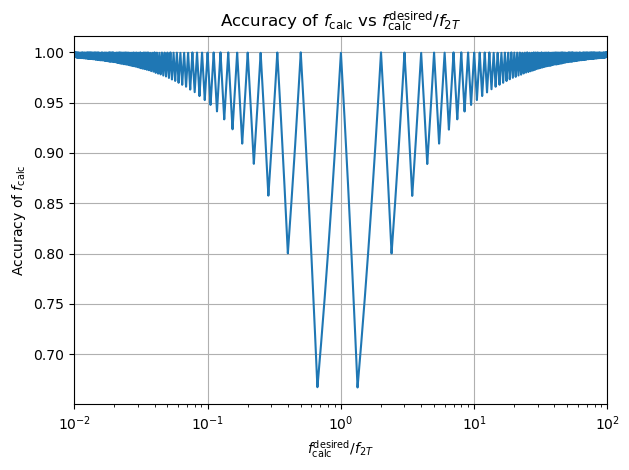

Average accuracy of f_calc approximation: 94.8%


In [14]:
# Generate eta_2T values
min_power = -2
max_power = 2
eta_2T_values = np.logspace(min_power, max_power, 10000)
#eta_2T_values = np.linspace(0.1, 3, 1000)

# Compute number_of_subhistories for each eta_2T
n_of_subhistories = [number_of_subhistories(eta_2T) for eta_2T in eta_2T_values]

# Compute f_calc and Theta for each N_pre
desired_f_calc_values = []
actual_f_calc_values = []
Theta_values = []
partial_theta_values = []
N_values = []
for eta_2T in eta_2T_values:
    desired_f_calc = 1./(eta_2T * _2T)
    actual_f_calc, Theta, N, partial_Theta = real_f_calc(eta_2T, _2T=_2T, N_eff=my_N_eff)
    desired_f_calc_values.append(desired_f_calc)
    partial_theta_values.append(partial_Theta)
    actual_f_calc_values.append(actual_f_calc)
    Theta_values.append(Theta)
    N_values.append(N)

# Sanity check
assert all(isinstance(N, int) for N in N_values), "Not all elements in N_values are integers."

# Convert to numpy arrays for easier manipulation
desired_f_calc_values = np.array(desired_f_calc_values)
actual_f_calc_values = np.array(actual_f_calc_values)
Theta_values = np.array(Theta_values)

# Calculate the relative f_calc error
f_calc_accuracy = np.abs(actual_f_calc_values - desired_f_calc_values) / desired_f_calc_values

plt.plot(eta_2T_values, 1-f_calc_accuracy, label='f_calc_accuracy')
#plt.plot(N_pre_values, case_values, label='case', color='orange')

# Add vertical color regions
#plt.axvspan(0, 1.0 - N_epsilon, color='blue', alpha=0.2, label='Case 1: $N^\mathrm{desired}$ < 1.0 - $\epsilon_N$')
#plt.axvspan(1.0 - N_epsilon, 1.0 + N_epsilon, color='green', alpha=0.2, label='Case 2: $N^\mathrm{desired}$ < 1.0 + $\epsilon_N$')
#plt.axvspan(1.0 + N_epsilon, max(N_pre_values), color='red', alpha=0.2, label='Case 3{0}'.format("a: $N^\mathrm{desired}$ > N_max" if case == 2 else "b: other"))

plt.xlim(10**min_power, 10**max_power)
plt.xscale('log')
#plt.ylim(0.999, 1.001)


# Add labels and title
plt.xlabel('$f^\mathrm{desired}_\mathrm{calc}/f_{2T}$')
plt.ylabel('Accuracy of $f_\mathrm{calc}$')
plt.title('Accuracy of $f_\mathrm{calc}$ vs $f^\mathrm{desired}_\mathrm{calc}/f_{2T}$')


# Add legend and grid
#plt.legend()
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()

print("Average accuracy of f_calc approximation: {0:.1f}%".format(np.mean(1-f_calc_accuracy)*100))

# Calculate average accuracy in the range of ```N_pre```

In [ ]:
# Integrate 1 - f_calc_accuracy
integral = np.trapz(1 - f_calc_accuracy, dx=(eta_2T_values[1] - eta_2T_values[0])) / eta_2T_values[-1]
print(f"Normalized integral of (1 - f_calc_accuracy): {integral:.3f}")

## Results

### Case 3a (```partial_theta = False```)

| Case 1 function | Case 3 function | ```N_epsilon``` | Case 3 rounding correction | Normalized integrated ```1 - f_calc_accuracy``` | Notes                           |
|-----------------|-----------------|-----------------|----------------------------|-------------------------------------------------|---------------------------------|
| ```np.ceil()``` | ```round()```   | 0,1             | not used                   | **0,813**                                       | Initial solution                |
| -\|\|-          | -\|\|-          | 0,25            | not used                   | **0,827**                                       | Optimized ```N_epsilon```       |
| ```round()```   | ```round()```   | 0,25            | not used                   | **0,835**                                       | Optimized Case 3 function       |
| ```round()```   | ```round()```   | 0,25            | +0,12                      | **0,840**                                       | Introduced and optimized coefficient in Case 3 |
|                 |                 |                 |                            |                                                 |                                 |